# 04 — Signed causal transplant (sufficiency)

Sufficiency-test для компонентов, которые прошли necessity-test через causal repair. На **clean** вход Detect head переносятся patched-значения выбранных координат. Главный вопрос: достаточно ли `top_negative` изменений, чтобы дозозависимо воспроизвести скрытие того же target?

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'new_experiments').exists()), None)
if REPO_ROOT is None: raise RuntimeError('Run from inside PatchSuccessResearch')
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

from CandidateRoutingAndAttackPath import load_experiment
from CandidateRoutingAndAttackPath.balanced_target_path import GROUP_ORDER
from CandidateRoutingAndAttackPath.causal_repair import load_causal_repair
from CandidateRoutingAndAttackPath.causal_transplant import (
    CausalTransplantConfig, load_causal_transplant, run_causal_transplant,
)
pd.set_option('display.max_columns', 100); pd.set_option('display.max_rows', 200)
plt.rcParams['figure.dpi'] = 110
print('repo:', REPO_ROOT)

repo: /Users/ashentide/PycharmProjects/PatchSuccessResearch


In [2]:
OUTPUT_ROOT = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs'
TRACE_DB = OUTPUT_ROOT / 'candidate_trace_b3c25981c3ad62d5' / 'candidate_tracing.sqlite'
ATTACK_PATH_DB = OUTPUT_ROOT / 'attack_path_0060cc9878ecdb6e' / 'attack_path.sqlite'
MANIFEST_CSV = OUTPUT_ROOT / 'target_instance_all_metrics' / 'balanced_target_selection_5e479438583b28b0' / 'balanced_target_manifest.csv'
REPAIR_DB = OUTPUT_ROOT / 'causal_repair_45b3c22295b10aba' / 'causal_repair.sqlite'
RUN_CAUSAL_TRANSPLANT = True
FORCE_CAUSAL_TRANSPLANT = False
MATCH_IOU, DETECTION_CONF = 0.50, 0.25

for path in [TRACE_DB, ATTACK_PATH_DB, MANIFEST_CSV]:
    if not path.exists(): raise FileNotFoundError(path)
exp, _ = load_experiment(repo_root=REPO_ROOT, prefer_dataset='COCO_people', prefer_device='mps', require_device=False)
transplant_config = CausalTransplantConfig(
    output_dir=str(OUTPUT_ROOT), max_output_gb=8.0, max_examples=None,
    k_values=(10, 50, 100, 250), random_repeats=3, forward_batch_size=8,
    detection_conf=DETECTION_CONF, match_iou=MATCH_IOU, seed=71, progress=True,
)
display(pd.Series({name: getattr(transplant_config, name) for name in transplant_config.__slots__}).to_frame('value'))

,value
output_dir,/Users/ashentide/PycharmProjects/PatchSuccessR...
max_output_gb,8.0
max_examples,None
k_values,"(10, 50, 100, 250)"
random_repeats,3
forward_batch_size,8
detection_conf,0.25
match_iou,0.5
nms_conf,0.01
nms_iou,0.7


## Дизайн

Стартовая точка — clean Detect-input. Для каждой выбранной координаты clean-значение заменяется patched-значением того же изображения.

- `top_negative`: основной causal transplant — координаты с самым сильным отрицательным вкладом в clean→patch target-logit;
- `top_positive`: sign control;
- `top_abs`: unsigned attribution control;
- `delta_magnitude`: крупнейшие изменения активаций без учёта output relevance;
- `random_delta_matched`: случайные координаты сопоставимой magnitude, 3 повтора;
- `patched_target_level` и `patched_full_head`: верхняя граница воспроизведения исходной атаки.

Главный endpoint — `attack_success`: после transplant target больше не имеет match при `IoU >= 0.5`, `confidence >= 0.25`. Дополнительно измеряются потери fixed-cell logit, post-NMS confidence и IoU. В SQLite сохраняются только числовые итоги; activation tensors не сохраняются.

In [3]:
if RUN_CAUSAL_TRANSPLANT:
    transplant_result = run_causal_transplant(
        exp, ATTACK_PATH_DB, TRACE_DB, MANIFEST_CSV, transplant_config,
        force=FORCE_CAUSAL_TRANSPLANT,
    )
    print('DB:', transplant_result.db_path)
    print('group summary:', transplant_result.group_summary_path)
    print('pairwise:', transplant_result.pairwise_path)
    print('digest:', transplant_result.digest_path)
else:
    raise RuntimeError('Set RUN_CAUSAL_TRANSPLANT=True or assign an existing transplant_result')

causal transplant:   0%|          | 0/400 [00:00<?, ?img/s]

DB: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/causal_transplant_edbd4a1533abd51f/causal_transplant.sqlite
group summary: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/causal_transplant_edbd4a1533abd51f/transplant_group_summary.csv
pairwise: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/causal_transplant_edbd4a1533abd51f/transplant_pairwise.csv
digest: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/causal_transplant_edbd4a1533abd51f/analysis_digest.md


In [4]:
transplant = load_causal_transplant(transplant_result)
display(pd.read_json(transplant_result.summary_path, typ='series').to_frame('value'))
unit = transplant.groupby(
    ['example_id', 'analysis_group', 'match_set', 'strategy', 'k_requested'], as_index=False
).agg(
    actual_k=('actual_k', 'mean'), target_logit_loss=('target_logit_loss', 'mean'),
    target_conf_loss=('target_conf_loss', 'mean'), target_iou_loss=('target_iou_loss', 'mean'),
    fixed_box_iou_loss=('fixed_box_iou_loss', 'mean'), attack_success=('attack_success', 'mean'),
    transplanted_delta_l1=('transplanted_delta_l1', 'mean'),
)
clean = unit.query("strategy == 'clean'").copy()
patched = unit.query("strategy == 'patched_full_head'").copy()
patched['expected_attack_success'] = patched.analysis_group.str.startswith('hidden').astype(int)
display(Markdown('### Sanity checks'))
print('clean baseline hidden rate:', clean.attack_success.mean())
display(pd.crosstab(patched.expected_attack_success, patched.attack_success, rownames=['expected patched outcome'], colnames=['recomputed']))
display(pd.read_csv(transplant_result.group_summary_path).head(100))

,value
status,complete
n_examples,400
expected_examples,400
n_rows,12400
expected_rows,12400
error_rows,0
group_counts,"{'hidden_low_conf_match': 100, 'hidden_no_iou_..."
strategies,"[clean, delta_magnitude, patched_full_head, pa..."
k_values,"[10, 50, 100, 250]"
database,/Users/ashentide/PycharmProjects/PatchSuccessR...


### Sanity checks

clean baseline hidden rate: 0.0


recomputed,0.0,1.0
expected patched outcome,,
0,200,0
1,7,193


,analysis_group,strategy,k_requested,n,n_rows,mean_actual_k,attack_success_rate,mean_target_logit,mean_logit_loss,mean_target_conf,mean_conf_loss,mean_target_max_iou,mean_iou_loss,mean_fixed_box_iou,mean_fixed_box_iou_loss,mean_transplanted_delta_l1
0,hidden_low_conf_match,clean,0,100,100,0.0,0.000000,2.255868,0.000000,0.903955,0.000000,1.000000,0.000000,1.000000,0.000000,NaN
1,hidden_low_conf_match,delta_magnitude,10,100,100,10.0,0.000000,2.251190,0.004678,0.903616,0.000339,0.995781,0.004219,0.996504,0.003496,77.071092
2,hidden_low_conf_match,delta_magnitude,50,100,100,50.0,0.000000,2.219660,0.036208,0.901445,0.002510,0.991485,0.008515,0.993231,0.006769,302.984668
3,hidden_low_conf_match,delta_magnitude,100,100,100,100.0,0.000000,2.170224,0.085644,0.898284,0.005671,0.987847,0.012153,0.989358,0.010642,537.874098
4,hidden_low_conf_match,delta_magnitude,250,100,100,250.0,0.000000,2.055079,0.200789,0.889354,0.014601,0.981039,0.018961,0.983013,0.016987,1130.244784
5,hidden_low_conf_match,patched_full_head,-1,100,100,-1.0,1.000000,-4.168212,6.424080,0.112753,0.791202,0.756444,0.243556,0.729205,0.270795,NaN
6,hidden_low_conf_match,patched_target_level,-1,100,100,-1.0,1.000000,-4.168212,6.424080,0.112753,0.791202,0.756444,0.243556,0.729205,0.270795,NaN
7,hidden_low_conf_match,random_delta_matched,10,100,300,10.0,0.000000,2.252025,0.003844,0.903695,0.000260,0.999203,0.000797,0.999584,0.000416,20.821840
8,hidden_low_conf_match,random_delta_matched,50,100,300,50.0,0.000000,2.243593,0.012275,0.903153,0.000802,0.997950,0.002050,0.998946,0.001054,86.820182
9,hidden_low_conf_match,random_delta_matched,100,100,300,100.0,0.000000,2.229357,0.026511,0.902148,0.001807,0.996953,0.003047,0.998323,0.001677,156.415618


## Sufficiency dose-response на исходно hidden группах

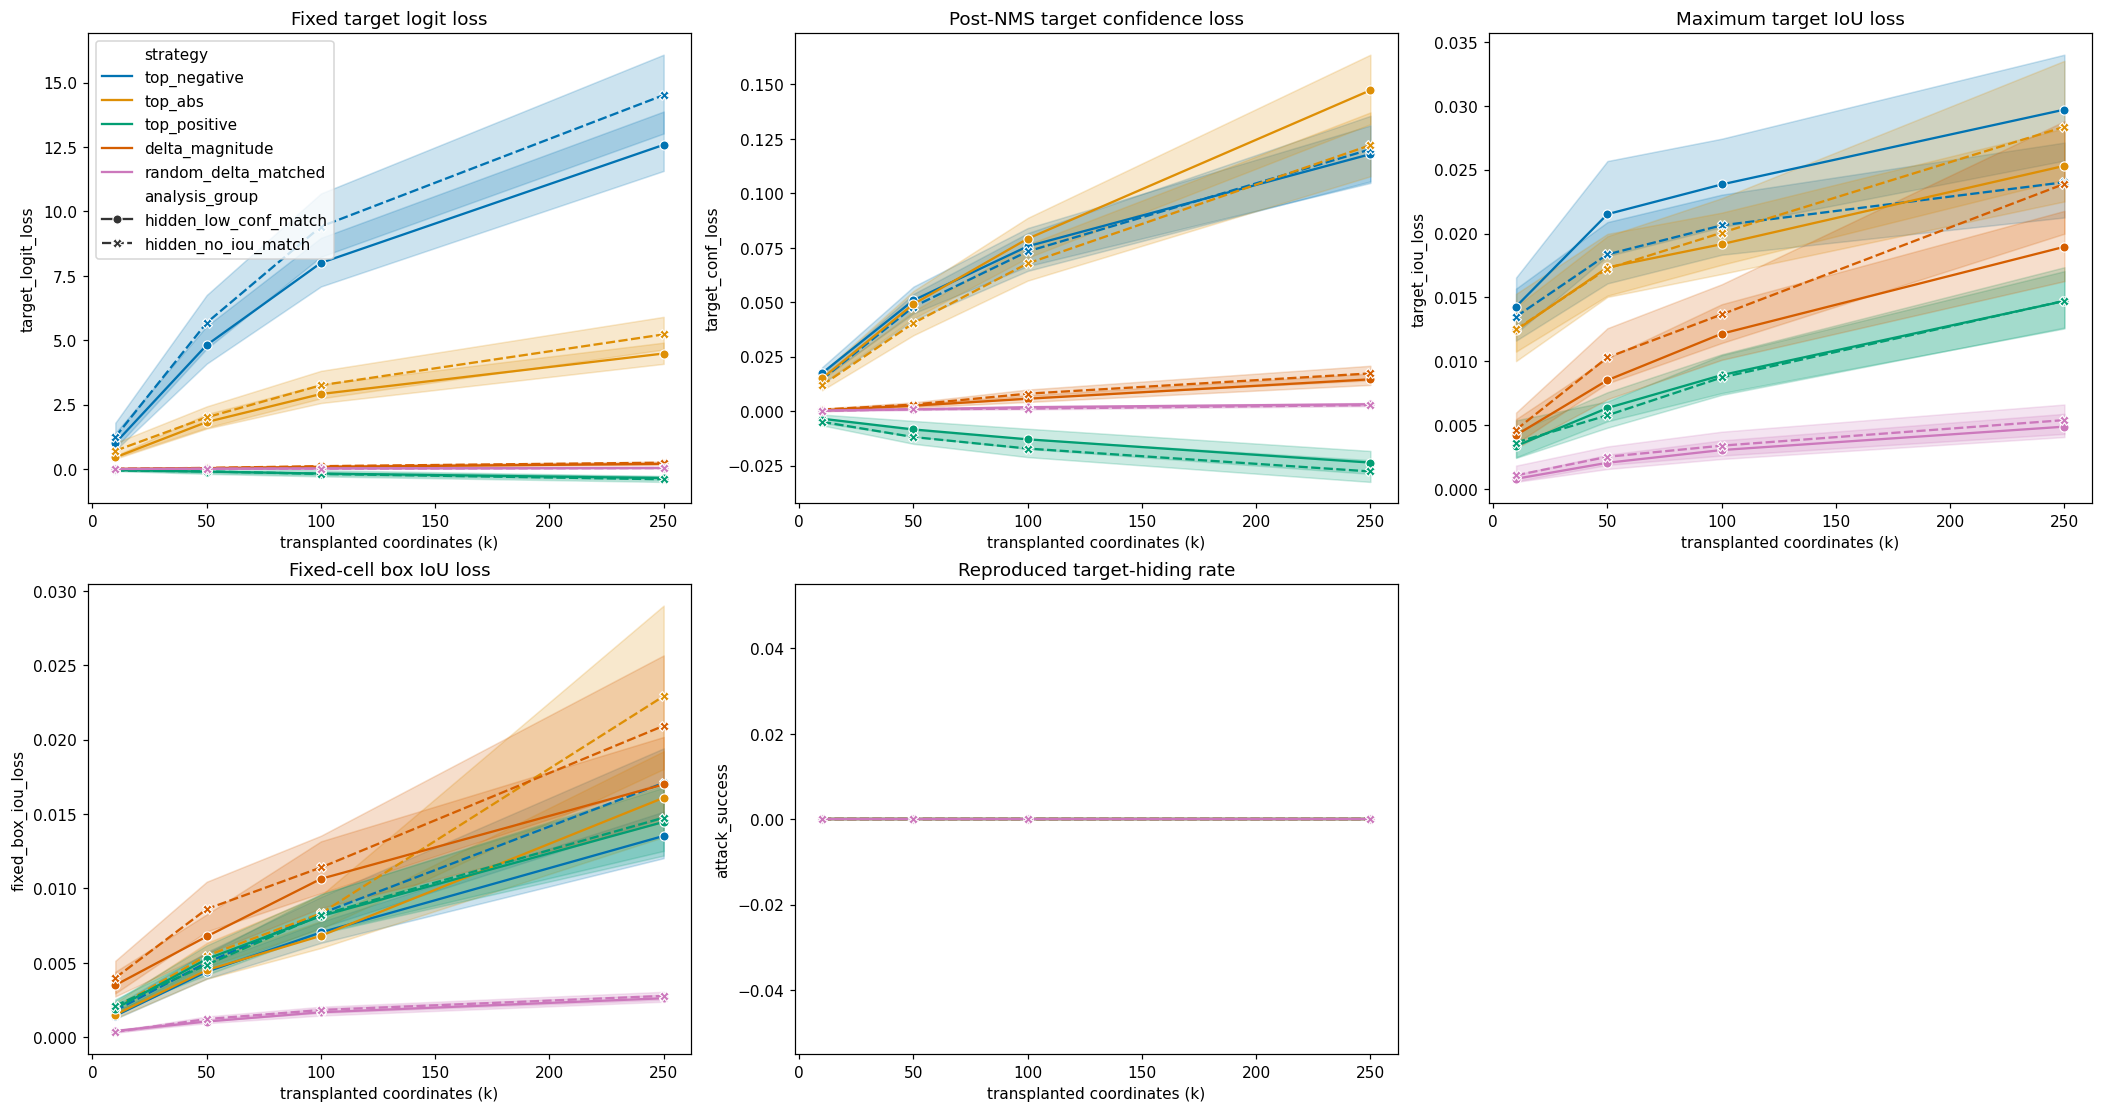

In [5]:
strategy_order = ['top_negative', 'top_abs', 'top_positive', 'delta_magnitude', 'random_delta_matched']
hidden_order = ['hidden_low_conf_match', 'hidden_no_iou_match']
selective_dose = unit.query('k_requested > 0 and strategy in @strategy_order').copy()
zero_source = unit.query("strategy == 'clean' and k_requested == 0").copy()
zero_dose = pd.concat([zero_source.assign(strategy=strategy) for strategy in strategy_order], ignore_index=True)
zero_dose['k_requested'] = 0
zero_dose['actual_k'] = 0
zero_dose['transplanted_delta_l1'] = 0.0
dose = pd.concat([zero_dose, selective_dose], ignore_index=True)
palette = dict(zip(strategy_order, sns.color_palette('colorblind', len(strategy_order))))
outcomes = [
    ('target_logit_loss', 'Fixed target logit loss'),
    ('target_conf_loss', 'Post-NMS target confidence loss'),
    ('target_iou_loss', 'Maximum target IoU loss'),
    ('fixed_box_iou_loss', 'Fixed-cell box IoU loss'),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
for ax, (metric, title) in zip(axes.flat, outcomes):
    sns.lineplot(
        data=dose[dose.analysis_group.isin(hidden_order)], x='k_requested', y=metric,
        hue='strategy', style='analysis_group', hue_order=strategy_order, style_order=hidden_order,
        palette=palette, markers=True, dashes=True, errorbar=('ci', 95), ax=ax,
    )
    ax.set(title=title, xlabel='transplanted coordinates (k)')
    if metric != 'target_logit_loss' and ax.get_legend() is not None: ax.get_legend().remove()
plt.show()

# Separate endpoint figure. Sparse k values are followed by two explicit dense-reference interventions.
k_values = sorted(int(value) for value in dose.k_requested.unique())
k_positions = {value: index for index, value in enumerate(k_values)}
hiding_dose = dose[dose.analysis_group.isin(hidden_order)].copy()
hiding_dose['dose_position'] = hiding_dose.k_requested.map(k_positions)
reference_order = ['patched_target_level', 'patched_full_head']
reference_labels = {'patched_target_level': 'all target level', 'patched_full_head': 'all head inputs'}
fig, axes = plt.subplots(1, 2, figsize=(17, 5.8), sharey=True, constrained_layout=True)
for ax, group in zip(axes, hidden_order):
    sns.lineplot(
        data=hiding_dose[hiding_dose.analysis_group.eq(group)], x='dose_position', y='attack_success',
        hue='strategy', hue_order=strategy_order, palette=palette, markers=True, dashes=False,
        errorbar=('ci', 95), ax=ax,
    )
    reference = (unit[unit.analysis_group.eq(group) & unit.strategy.isin(reference_order)]
                 .groupby('strategy').attack_success.mean().reindex(reference_order))
    reference_positions = [len(k_values), len(k_values) + 1]
    for position, strategy, marker in zip(reference_positions, reference_order, ['D', '*']):
        ax.scatter(position, reference[strategy], s=120, marker=marker, color='black',
                   label=reference_labels[strategy], zorder=5)
    ax.plot(reference_positions, reference.values, color='black', linestyle=':', alpha=.6)
    ax.set(
        title=group, ylabel='reproduced target-hiding rate', ylim=(-.03, 1.05),
        xlabel='selective transplanted coordinates k → dense reference',
        xticks=list(range(len(k_values) + 2)),
        xticklabels=[str(value) for value in k_values] + ['all target\nlevel', 'all head\ninputs'],
    )
    ax.tick_params(axis='x', rotation=25)
    if ax is not axes[0] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0].legend(title='strategy / dense reference', bbox_to_anchor=(0, 1), loc='upper left')
fig.suptitle('Reproduced target hiding across the complete intervention range', fontsize=15)
plt.show()

**Первая фигура.** Все стратегии начинаются с общего clean baseline при `k=0`, где все loss-метрики равны нулю. От него перенос `top_negative` patched-значений очень сильно и дозозависимо подавляет logit исходной clean-ячейки: при `k=250` loss достигает `12.59` для low-confidence и `14.51` для no-IoU. `top_abs` слабее (`4.48/5.23`), `delta_magnitude` и random почти не меняют logit, а `top_positive` слегка повышает его. Следовательно, signed attribution действительно выделяет достаточный набор для управления локальным class-logit.

**Отдельная вторая фигура.** Для sparse transplant reproduced hiding остаётся ровно `0%` на всей экспериментальной сетке от `k=0` до `k=250`. Конечные чёрные точки — не очередные значения sparse `k`, а плотные reference-интервенции: перенос всех активаций target-level воспроизводит hiding в `100%/93%`, и перенос всех входов head даёт тот же результат. Поэтому между `k=250` и `all target level` нельзя интерполировать как между соседними дозами одной стратегии: фигура показывает границу между выбранным локальным support и полным распределённым состоянием уровня. Confidence loss при `k=250` составляет лишь около `0.12`, а IoU loss около `0.03`: сильное подавление исходной ячейки компенсируется другими кандидатами. Fixed-cell logit не является достаточным mediator итоговой post-NMS детекции.

## Specificity across all matched groups

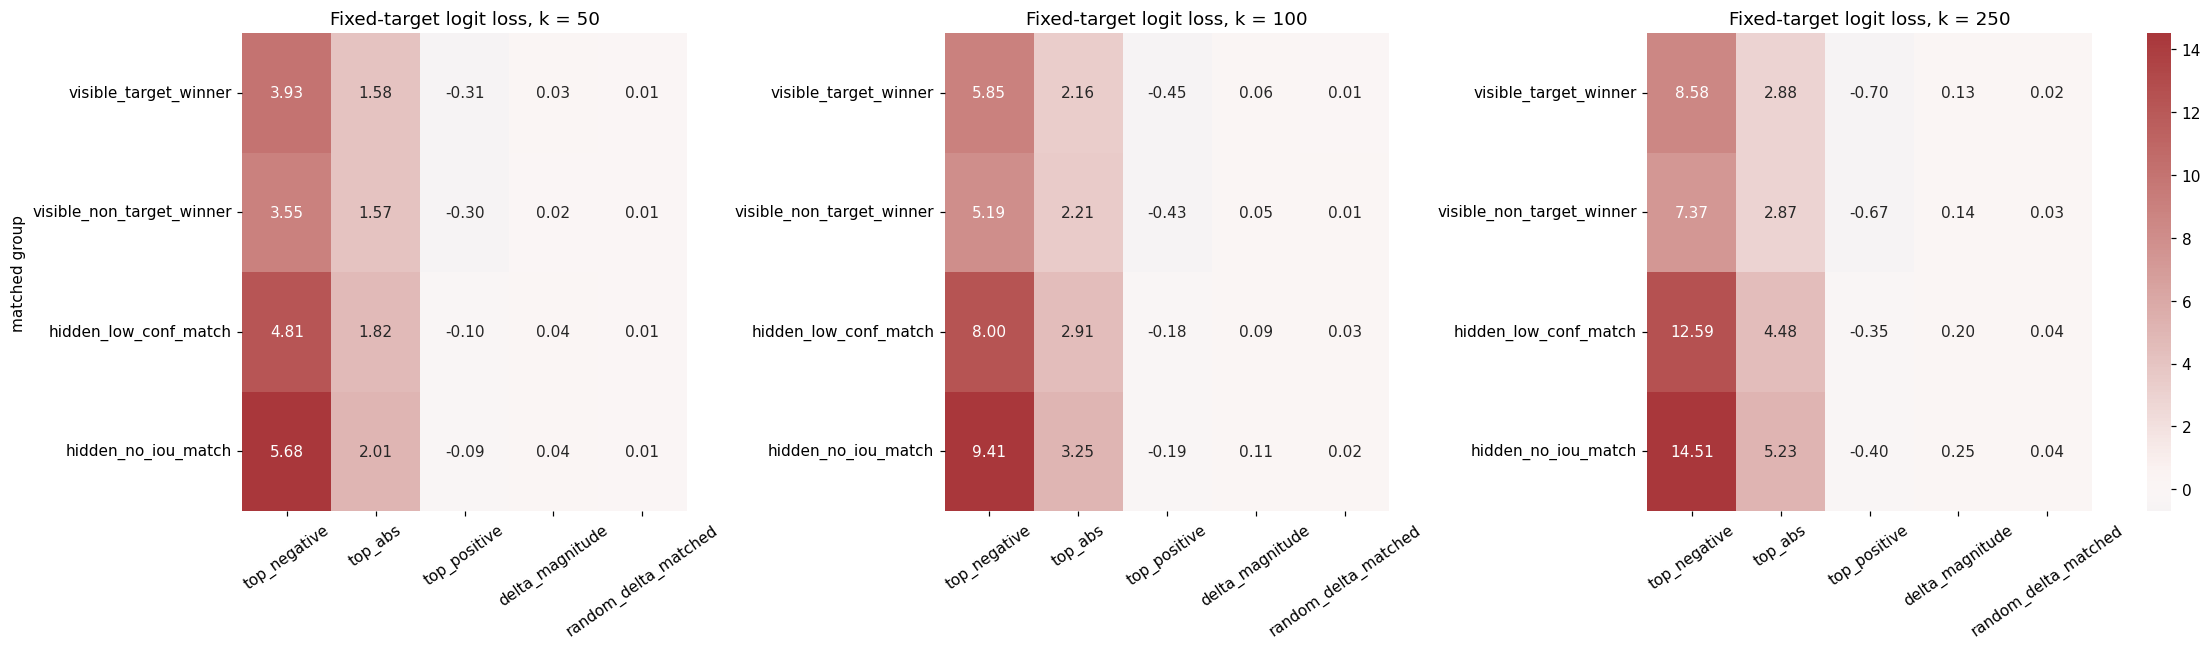

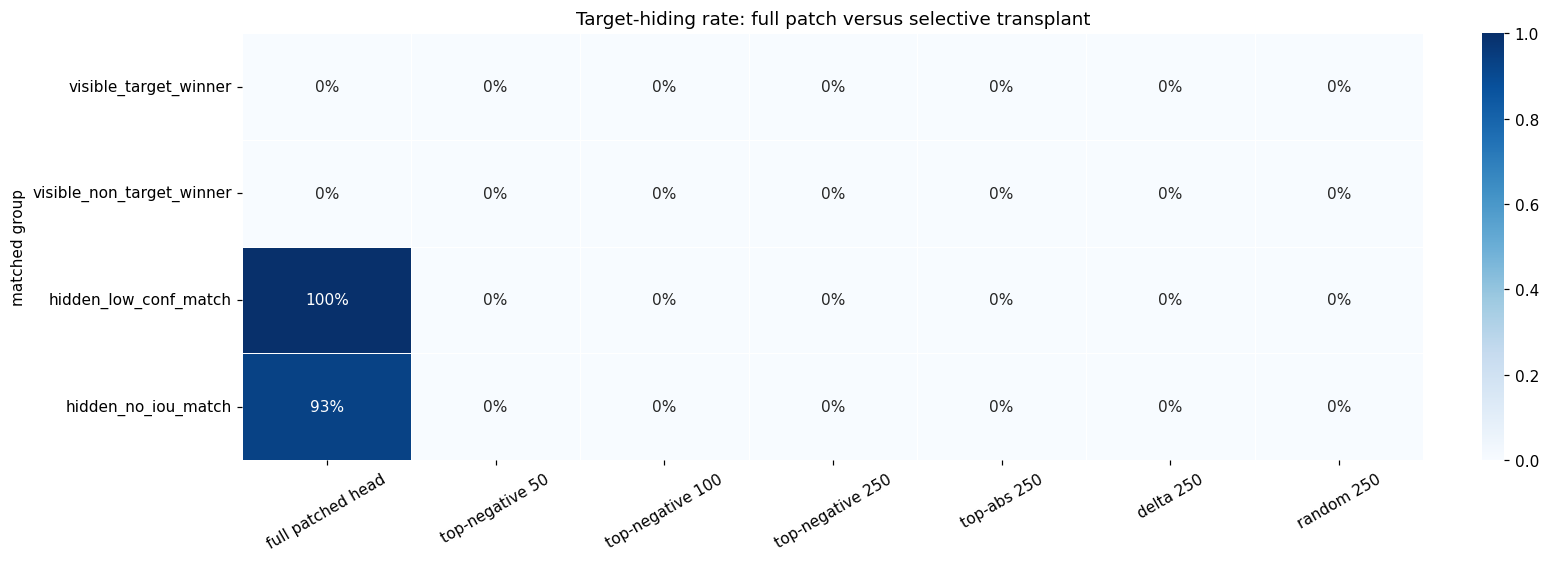

Selective transplant did not hide any target at k >= 50; zeros are the result, not missing data.


In [6]:
display(Markdown('## Specificity across all matched groups'))
fig, axes = plt.subplots(1, 3, figsize=(20, 5.8), constrained_layout=True)
for ax, k in zip(axes, [50, 100, 250]):
    logit_table = dose[dose.k_requested.eq(k)].pivot_table(
        index='analysis_group', columns='strategy', values='target_logit_loss', aggfunc='mean',
    ).reindex(index=GROUP_ORDER, columns=strategy_order)
    sns.heatmap(logit_table, annot=True, fmt='.2f', center=0, cmap='vlag', cbar=k == 250, ax=ax)
    ax.set_title(f'Fixed-target logit loss, k = {k}'); ax.set_xlabel(''); ax.set_ylabel('' if k != 50 else 'matched group')
    ax.tick_params(axis='x', rotation=35)
plt.show()

endpoint_specs = [
    ('patched_full_head', -1, 'full patched head'),
    ('top_negative', 50, 'top-negative 50'),
    ('top_negative', 100, 'top-negative 100'),
    ('top_negative', 250, 'top-negative 250'),
    ('top_abs', 250, 'top-abs 250'),
    ('delta_magnitude', 250, 'delta 250'),
    ('random_delta_matched', 250, 'random 250'),
]
endpoint_parts = []
for strategy, k, label in endpoint_specs:
    part = unit[unit.strategy.eq(strategy) & unit.k_requested.eq(k)].copy()
    part['variant'] = label
    endpoint_parts.append(part)
endpoint = pd.concat(endpoint_parts, ignore_index=True).pivot_table(
    index='analysis_group', columns='variant', values='attack_success', aggfunc='mean',
).reindex(index=GROUP_ORDER, columns=[label for _, _, label in endpoint_specs])
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
sns.heatmap(endpoint, annot=True, fmt='.0%', vmin=0, vmax=1, cmap='Blues', linewidths=.5, ax=ax)
ax.set(title='Target-hiding rate: full patch versus selective transplant', xlabel='', ylabel='matched group')
ax.tick_params(axis='x', rotation=30)
plt.show()
if dose.loc[dose.k_requested.ge(50), 'attack_success'].max() == 0:
    print('Selective transplant did not hide any target at k >= 50; zeros are the result, not missing data.')

**Первая фигура.** `top_negative` подавляет fixed-target logit во всех matched-группах, но количественно сильнее на исходно hidden: при `k=250` loss равен `12.59/14.51` против `8.58/7.37` в visible-группах. Это согласуется с более сильным causal path у успешных атак, однако эффект не является уникальным для success. Остальные controls на порядок слабее, поэтому локальная специфичность attribution подтверждается.

**Вторая фигура.** Полный patched Detect-input воспроизводит дизайн (`100%` hiding для low-confidence и `93%` для no-IoU), тогда как ни один selective transplant не скрывает target — даже `top_negative k=250`, несмотря на огромный logit loss. Нули присутствуют также у visible-контролей, поэтому это не ошибка построения. Вывод: выбранные координаты necessary для исходной ячейки, но сеть имеет достаточную candidate redundancy, чтобы сохранить человека через winner promotion/rerouting.

In [7]:
pairwise = pd.read_csv(transplant_result.pairwise_path)
primary = pairwise[
    pairwise.analysis_group.isin(hidden_order)
    & pairwise.metric.isin(['target_logit_loss', 'target_conf_loss', 'target_iou_loss', 'attack_success'])
].sort_values(['analysis_group', 'k_requested', 'metric', 'control'])
display(Markdown('## Paired advantage of top-negative'))
display(primary[[
    'analysis_group', 'k_requested', 'control', 'metric', 'n', 'primary_mean',
    'control_mean', 'mean_difference', 'ci95_low', 'ci95_high', 'p_holm',
]])
print('Positive difference = top_negative reproduces more of the attack.')

## Paired advantage of top-negative

,analysis_group,k_requested,control,metric,n,primary_mean,control_mean,mean_difference,ci95_low,ci95_high,p_holm
14,hidden_low_conf_match,10,delta_magnitude,attack_success,100,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00
19,hidden_low_conf_match,10,random_delta_matched,attack_success,100,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00
4,hidden_low_conf_match,10,top_abs,attack_success,100,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00
9,hidden_low_conf_match,10,top_positive,attack_success,100,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00
11,hidden_low_conf_match,10,delta_magnitude,target_conf_loss,100,0.017421,0.000339,0.017083,0.014593,0.019781,3.529470e-15
16,hidden_low_conf_match,10,random_delta_matched,target_conf_loss,100,0.017421,0.000260,0.017161,0.014709,0.019852,4.049627e-15
1,hidden_low_conf_match,10,top_abs,target_conf_loss,100,0.017421,0.015002,0.002419,0.001101,0.003695,2.263362e-02
6,hidden_low_conf_match,10,top_positive,target_conf_loss,100,0.017421,-0.003496,0.020917,0.017845,0.024102,1.016897e-14
12,hidden_low_conf_match,10,delta_magnitude,target_iou_loss,100,0.014280,0.004219,0.010061,0.007710,0.012376,3.861570e-11
17,hidden_low_conf_match,10,random_delta_matched,target_iou_loss,100,0.014280,0.000797,0.013483,0.011450,0.015670,1.246899e-15


Positive difference = top_negative reproduces more of the attack.


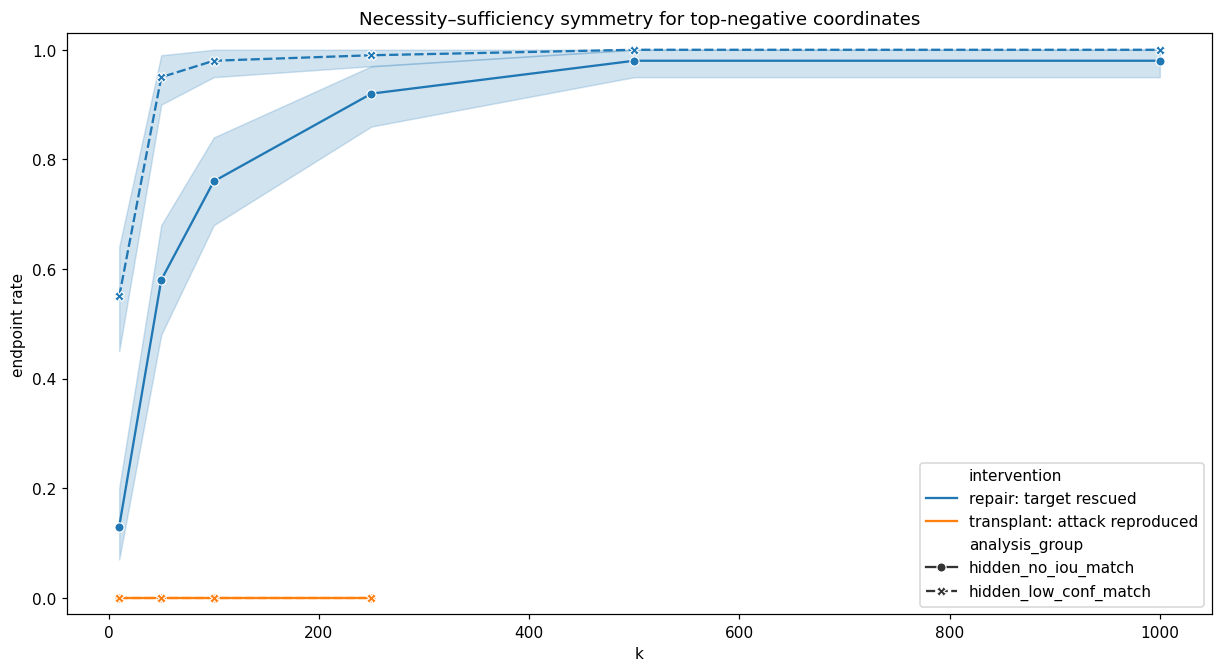

: 

In [ ]:
if REPAIR_DB.exists():
    repair = load_causal_repair(REPAIR_DB)
    repair_selective = repair[
        repair.analysis_group.isin(hidden_order) & repair.strategy.eq('top_negative') & repair.k_requested.gt(0)
    ].groupby(['example_id', 'analysis_group', 'k_requested'], as_index=False).target_detected.mean()
    repair_zero = repair[
        repair.analysis_group.isin(hidden_order) & repair.strategy.eq('patched') & repair.k_requested.eq(0)
    ].groupby(['example_id', 'analysis_group', 'k_requested'], as_index=False).target_detected.mean()
    repair_curve = pd.concat([repair_zero, repair_selective], ignore_index=True)
    repair_curve = repair_curve.rename(columns={'target_detected': 'rate'}).assign(intervention='repair: target rescued')
    transplant_curve = dose[
        dose.analysis_group.isin(hidden_order) & dose.strategy.eq('top_negative') & dose.k_requested.ge(0)
    ][['example_id', 'analysis_group', 'k_requested', 'attack_success']].rename(columns={'attack_success': 'rate'}).assign(intervention='transplant: attack reproduced')
    symmetry = pd.concat([repair_curve, transplant_curve], ignore_index=True)
    fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
    sns.lineplot(
        data=symmetry, x='k_requested', y='rate', hue='intervention', style='analysis_group',
        markers=True, dashes=True, errorbar=('ci', 95), ax=ax,
    )
    ax.set(title='Necessity–sufficiency symmetry for top-negative coordinates', xlabel='k', ylabel='endpoint rate', ylim=(-0.03, 1.03))
    plt.show()
else:
    print('Repair DB not found; symmetry plot skipped:', REPAIR_DB)

**Что видно на графике.** Для тех же `top_negative` coordinates repair быстро спасает target: low-confidence достигает примерно `95%` уже при `k=50`, no-IoU — `58%`, затем обе кривые стремятся к `≈1`. Обратный transplant при всех `k` остаётся на `0%`. Получается резкая necessity–sufficiency асимметрия: удаление этих изменений из patched-состояния разрушает атаку, но добавление их в clean-состояние не создаёт её. Это характерно для системы с резервными маршрутами/взаимодействиями, а не для единственного независимого causal bottleneck.

## Как принимать решение

1. `top_negative` дозозависимо воспроизводит target hiding и превосходит random/delta controls — найденный mediator set не только необходим, но и частично достаточен.
2. Logit падает, но confidence/IoU и attack success не следуют за ним — class-selected set недостаточен для geometry/routing; следующий эксперимент должен отдельно атрибутировать box branch.
3. `top_abs` равен `top_negative` — знак не даёт дополнительной специфичности; достаточно unsigned causal support.
4. `delta_magnitude` или magnitude-matched random дают тот же эффект — path attribution не выделяет специфический механизм.
5. Эффект одинаково силён на исходно visible и hidden группах — координаты являются общим рычагом target score, но не объясняют различие успеха.
6. Сильный эффект только в hidden-группах — mediator set специфичен для успешной атаки и особенно ценен как кандидат механизма.